# Bayesian Linear Regression via BlackJAX Nested Sampling

 This minimal example demonstrates Bayesian parameter estimation for a simple linear model using adaptive nested sampling. Synthetic data is generated from a linear model with parameters for slope, intercept, and noise level. The example sets up the likelihood and uniform priors, samples the posterior using blackJAX’s nested sampling routine, and finally post-processes the samples with the `anesthetic` package for in-depth visualization and analysis.

## Installation
```bash
 pip install git+https://github.com/handley-lab/blackjax
 pip install git++https://github.com/handley-lab/anesthetic
 pip install tqdm
```

In [1]:
import jax
import jax.numpy as jnp
import tqdm
import blackjax

jax.config.update("jax_enable_x64", True)

## 0. Nested Sampling parameters
 
 - `num_dims` is the number of parameters you are fitting for
 - `num_live` is a resolution parameter. evidence and posteriors get better as sqrt(nlive), runtime increases linearly with num_live 
 - `num_inner_steps` is a reliability parameter. Setting this too low degrades results, but there is no gain to arbitrarily increasing it. Best practice is to check that halving or doubling it doesn't change the results. runtime increases linearly with num_inner_steps
 - `num_delete` is a parallelisation parameter. You shouldn't need to change this.

In [2]:
rng_key = jax.random.PRNGKey(0)
num_dims = 3
num_live = 1000
num_inner_steps = num_dims * 5
num_delete = num_live // 2

## 1. Define data and likelihood
 
 This problem consists of fitting a `y=mx+c` model to data, where the gradient `m`, intercept `c` and noise level `sigma` are to be fitted for from a set of (x, y) data points.
 In this instance the true model has $m=2, c=1, \sigma=1$.

In [3]:
num_data = 10
xmin, xmax = -1.0, 1.0
x = jnp.linspace(xmin, xmax, num_data)
m = 2.0
c = 1.0
sigma = 1
key, rng_key = jax.random.split(rng_key)
noise = sigma * jax.random.normal(key, (num_data,)) 
y = m * x + c + noise

Easiest just to plot the data to see.

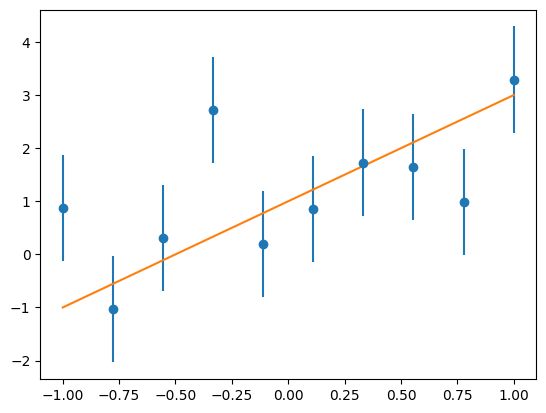

In [4]:
import matplotlib.pyplot as plt

plt.errorbar(x, y, yerr=sigma, fmt="o", label="data")
plt.plot(x, m * x + c, label="true model")

## 2. Define the likelihood function

 Here we just make use of the `scipy` multivariate normal distribution to define the likelihood function, which is normal in the data.

In [31]:
def loglikelihood_fn(params):
    m = params["m"]
    c = params["c"]
    sigma = params["sigma"]
    cov = sigma ** 2
    #print(f"m: {m.shape}, c: {c.shape}, sigma: {sigma.shape}, cov: {cov.shape}")
    return jax.scipy.stats.multivariate_normal.logpdf(y, m * x + c, cov)

## 3. Define the prior function

 Here we use uniform priors for the parameters.

In [54]:
prior_bounds = {
        "m": (-5.0, 5.0),
        "c": (-5.0, 5.0),
        "sigma": (0.0, 10.0),
        }

rng_key, prior_key = jax.random.split(rng_key)
particles, logprior_fn = blackjax.ns.utils.uniform_prior(prior_key, num_live, prior_bounds)

In [33]:
particles

{'c': Array([ 0.90282045,  0.03623368,  2.88760863, -4.91692352,  4.61203233,
         0.75542413, -2.72354122,  2.03772696,  2.80177212,  3.65148516,
         3.02038922,  3.98333838,  2.43260446,  3.11721793,  1.42108188,
        -4.88870455,  4.01118425, -0.75464816,  3.93092195,  2.95568345,
        -3.46271334, -1.86290574, -1.48103815, -1.75572789,  1.37042853,
         0.86871352,  1.65232568,  4.71043119, -4.65280993, -1.66073356,
        -1.45690039,  3.12923256,  4.68293199,  1.75371104,  2.76825791,
        -1.17257648, -3.04344057, -4.71481884,  1.2256899 ,  3.67474404,
         0.58825289, -4.62181878, -4.76030926,  1.96163697, -1.63318745,
         3.88526708,  4.97569148, -3.52154335, -2.69142294, -2.41649121,
         1.11959385, -1.13177837, -3.16262844,  4.45156477,  4.18507851,
         4.66573589,  3.27656437,  4.09537666, -3.90869904,  4.8547064 ,
         4.70064467, -1.21527774,  0.02180746,  4.7286324 , -1.07592328,
        -1.48838337,  1.72452858, -3.75250999,

## 4. Run Nested Sampling

In [51]:
nested_sampler = blackjax.nss(
    logprior_fn=logprior_fn,
    loglikelihood_fn=loglikelihood_fn,
    num_delete=num_delete,
    num_inner_steps=num_inner_steps,
)
init_fn = jax.jit(nested_sampler.init)
step_fn = jax.jit(nested_sampler.step)

live = init_fn(particles)
live

NSState(particles={'c': Array([ 0.90282045,  0.03623368,  2.88760863, -4.91692352,  4.61203233,
        0.75542413, -2.72354122,  2.03772696,  2.80177212,  3.65148516,
        3.02038922,  3.98333838,  2.43260446,  3.11721793,  1.42108188,
       -4.88870455,  4.01118425, -0.75464816,  3.93092195,  2.95568345,
       -3.46271334, -1.86290574, -1.48103815, -1.75572789,  1.37042853,
        0.86871352,  1.65232568,  4.71043119, -4.65280993, -1.66073356,
       -1.45690039,  3.12923256,  4.68293199,  1.75371104,  2.76825791,
       -1.17257648, -3.04344057, -4.71481884,  1.2256899 ,  3.67474404,
        0.58825289, -4.62181878, -4.76030926,  1.96163697, -1.63318745,
        3.88526708,  4.97569148, -3.52154335, -2.69142294, -2.41649121,
        1.11959385, -1.13177837, -3.16262844,  4.45156477,  4.18507851,
        4.66573589,  3.27656437,  4.09537666, -3.90869904,  4.8547064 ,
        4.70064467, -1.21527774,  0.02180746,  4.7286324 , -1.07592328,
       -1.48838337,  1.72452858, -3.7525

In [52]:
live.logZ_live

Array(-inf, dtype=float64, weak_type=True)

In [53]:
print("Initial logZ:", live.logZ)
print("Initial logZ_live:", live.logZ_live)

if not jnp.isfinite(live.logZ):
    raise ValueError("Initial particles contain no valid log-likelihoods.")

Initial logZ: -inf
Initial logZ_live: -inf


ValueError: Initial particles contain no valid log-likelihoods.

In [48]:
nested_sampler = blackjax.nss(
    logprior_fn=logprior_fn,
    loglikelihood_fn=loglikelihood_fn,
    num_delete=num_delete,
    num_inner_steps=num_inner_steps,
)
init_fn = jax.jit(nested_sampler.init)
step_fn = jax.jit(nested_sampler.step)

live = init_fn(particles)

dead = []
with tqdm.tqdm(desc="Dead points", unit=" dead points") as pbar:
    while not live.logZ_live - live.logZ < -3:
        print(f"Current logZ: {live.logZ_live - live.logZ}")
        rng_key, subkey = jax.random.split(rng_key, 2)
        live, dead_info = step_fn(subkey, live)
        dead.append(dead_info)
        pbar.update(num_delete)

dead = blackjax.ns.utils.finalise(live, dead)

Dead points: 0 dead points [00:00, ? dead points/s]

[0] logZ = -inf, ΔlogZ = nan


Dead points: 500 dead points [00:01, 470.50 dead points/s]

[1] logZ = -33.032, ΔlogZ = 12.118


Dead points: 7500 dead points [00:02, 2986.55 dead points/s]

[2] logZ = -30.347, ΔlogZ = 9.068
[3] logZ = -28.589, ΔlogZ = 7.631
[4] logZ = -27.037, ΔlogZ = 5.867
[5] logZ = -25.735, ΔlogZ = 4.750
[6] logZ = -24.586, ΔlogZ = 3.585
[7] logZ = -23.635, ΔlogZ = 2.505
[8] logZ = -22.847, ΔlogZ = 1.579
[9] logZ = -22.250, ΔlogZ = 0.783
[10] logZ = -21.822, ΔlogZ = 0.075
[11] logZ = -21.528, ΔlogZ = -0.605
[12] logZ = -21.343, ΔlogZ = -1.255
[13] logZ = -21.232, ΔlogZ = -1.894
[14] logZ = -21.168, ΔlogZ = -2.543
Stopping: ΔlogZ threshold reached.


In [55]:
dead

[NSInfo(particles={'c': Array([ 4.61820061, -4.27533567, -3.4221578 , -4.60528005, -4.69645058,
        -0.54711431,  1.41052402, -3.60722155,  2.95712291,  0.87297801,
         3.38595641, -4.91864269,  4.58999187, -4.63645052, -1.06715469,
         3.89067738, -4.79778169, -2.95632214, -2.3059168 , -2.37200446,
        -3.61580305, -2.69009176,  4.34919689, -4.82611914, -2.62892629,
         4.59650488, -1.66073356, -4.41753407,  0.60745211, -2.14971912,
        -2.72354122, -4.56238572,  2.02246143, -3.97432689, -3.13999616,
         4.68293199,  1.87646822, -1.9245031 , -4.78891711, -3.91084178,
        -2.41649121,  2.49169811,  0.98184739, -3.65532123, -1.03432253,
        -4.93725093, -3.58428608,  3.4249751 ,  2.21262453,  3.19213689,
         2.6677354 , -4.95652729, -4.84264798,  1.08403684, -3.18281029,
         4.94966921, -4.25726459,  2.36200448,  4.0967292 , -3.56156703,
         2.03260483,  3.38934177,  2.77848005,  1.69774558,  3.50820624,
        -4.90538802, -2.1249

In [45]:

dead = []
with tqdm.tqdm(desc="Dead points", unit=" dead points") as pbar:
    while not live.logZ_live - live.logZ < -3:
        print(f"Current logZ: {live.logZ_live - live.logZ}")
        rng_key, subkey = jax.random.split(rng_key, 2)
        live, dead_info = step_fn(subkey, live)
        dead.append(dead_info)
        pbar.update(num_delete)

dead = blackjax.ns.utils.finalise(live, dead)

Dead points: 0 dead points [00:00, ? dead points/s]

Stopping: ΔlogZ threshold reached.


In [46]:
len(dead)

0

## 5. Save the data as a csv

 This uses the anesthetic tool, a nested sampler agnostic software package for processing and plotting nested sampling results (think getdist, arviz, corner.py, but specialised for nested sampling). 

 You may prefer other posterior plotting packages, but should be aware of this for the nested sampling specific pieces, including but not limited to:
 - `samples.logZ()` - the log evidence
 - `samples.logZ(n)` - samples from the evidence distribution
 - `samples.gui()` - a GUI for exploring the nested sampling run
    - also accessible as an executable `anesthetic line.csv` if you've saved the samples.
 - `samples.prior()` - the prior samples
 - `samples.live_points(i)` - the live points at any point in the run

In [37]:
from anesthetic import NestedSamples
columns = ["m", "c", "sigma"]
labels = [r"$m$", r"$c$", r"$\sigma$"]
data = jnp.vstack([dead.particles[key] for key in columns]).T
samples = NestedSamples(
    data,
    logL=dead.loglikelihood,
    logL_birth=dead.loglikelihood_birth,
    columns=columns,
    labels=labels,
    logzero=jnp.nan,
)
samples.to_csv("line.csv")

## 7. Plot results

 The rest of this script showcases nested sampling plotting and analysis capabilities

load results from file if you're returning to this script later

In [9]:
from anesthetic import read_chains
samples = read_chains("line.csv")

### Plot the posterior with anesthetic

 For more detail have a look at 
 https://anesthetic.readthedocs.io/en/latest/plotting.html

,m,c,sigma
m,DiagonalAx...,OffDiagona...,OffDiagona...
c,OffDiagona...,DiagonalAx...,OffDiagona...
sigma,OffDiagona...,OffDiagona...,DiagonalAx...


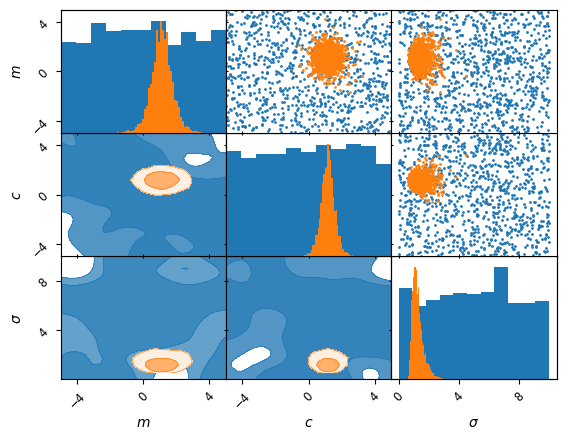

In [10]:
kinds ={'lower': 'kde_2d', 'diagonal': 'hist_1d', 'upper': 'scatter_2d'}
axes = samples.prior().plot_2d(['m', 'c', 'sigma'], kinds=kinds, label='prior')
samples.plot_2d(axes, kinds=kinds, label='posterior')

Plot the functional posterior

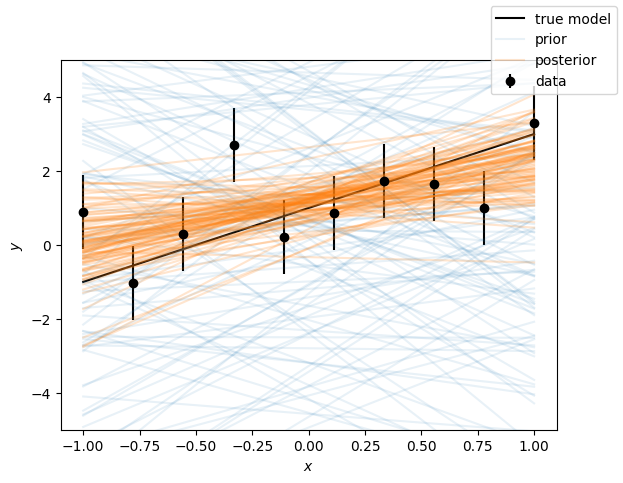

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

# Plot the data
ax.errorbar(x, y, yerr=sigma, fmt="o", label="data", color='k')
ax.plot(x, m * x + c, label="true model", color='k')

# Get samples from the function y=mx+c
m_ = samples.m.values[:, None]
c_ = samples.c.values[:, None]
y_ = m_ * x  + c_
yvals = [f'y_{i}' for i in range(num_data)]
samples[yvals] = y_

# Plot the prior and posterior function samples
lines = ax.plot(x, samples.prior()[yvals].sample(100).T, color="C0", alpha=0.1)
lines[0].set_label("prior")
lines = ax.plot(x, samples[yvals].sample(100).T, color="C1", alpha=0.2)
lines[0].set_label("posterior")

# tidy up
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_ylim(-5, 5)
fig.legend()